In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.preprocessing import StandardScaler

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
df =  pd.read_csv('insuranceWithFeatures.csv')
print(df.head())

   age     sex     bmi  children smoker     region      charges  smoker-age  \
0   19  female  27.900         0    yes  southwest  16884.92400          19   
1   18    male  33.770         1     no  southeast   1725.55230           0   
2   28    male  33.000         3     no  southeast   4449.46200           0   
3   33    male  22.705         0     no  northwest  21984.47061           0   
4   32    male  28.880         0     no  northwest   3866.85520           0   

   Sex-Weight  sexBool  smokerBool  regionSouthWest  regionSouthEast  \
0        27.9        1           1                1                0   
1         0.0        0           0                0                1   
2         0.0        0           0                0                1   
3         0.0        0           0                0                0   
4         0.0        0           0                0                0   

   regionNorthWest  log_charges  
0                0     9.734236  
1                0     7

In [13]:
def build_mc_dropout_model(input_dim, output_dim=1, hidden_units=[64, 64], dropout_rate=0.2):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
        x = layers.Dropout(dropout_rate)(x)  # active during inference too

    outputs = layers.Dense(output_dim)(x)  # works for single or multi-output
 
    model = keras.Model(inputs, outputs)
    return model

In [19]:
X = df[["age", "smokerBool", "children", "sexBool", "bmi"]].values
y = df["charges"].values

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = build_mc_dropout_model(input_dim=5, output_dim=1)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 322425536.0000 - mae: 13345.1836
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 322318752.0000 - mae: 13341.8818
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 322080608.0000 - mae: 13334.6045
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321596288.0000 - mae: 13320.1260
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 320687328.0000 - mae: 13294.5488
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 319119232.0000 - mae: 13252.5107
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 316790464.0000 - mae: 13191.3936
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 313411552.0000 - mae: 13102.9443
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 308871200.0000 - mae: 12989.7422
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 303263008.0000 - mae: 12844.3994
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 295819200.0000 - ma

In [29]:
def mc_dropout_predict(model, X, n_samples=100):
    preds = []

    for _ in range(n_samples):
        y_pred = model(X, training=True)  # turn dropout on
        preds.append(y_pred.numpy())

    preds = np.array(preds)  # shape: (n_samples, batch_size, output_dim)

    mean = preds.mean(axis=0)
    std = preds.std(axis=0)
    #For classifictaion
    #outputs = layers.Dense(num_classes, activation="softmax")(x)  
    return mean, std

In [55]:
mean_pred, std_pred = mc_dropout_predict(model, X_test, n_samples=100)

i = 100 # sample number in test

print("mean pred", mean_pred[i])  
print("std", std_pred[i])

mean pred [4456.1445]
std [658.8479]


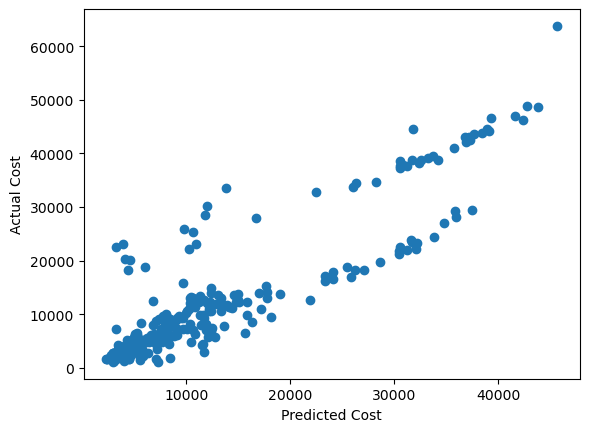

In [43]:
plt.scatter(mean_pred, y_test)
plt.xlabel("Predicted Cost")
plt.ylabel("Actual Cost")
plt.show()

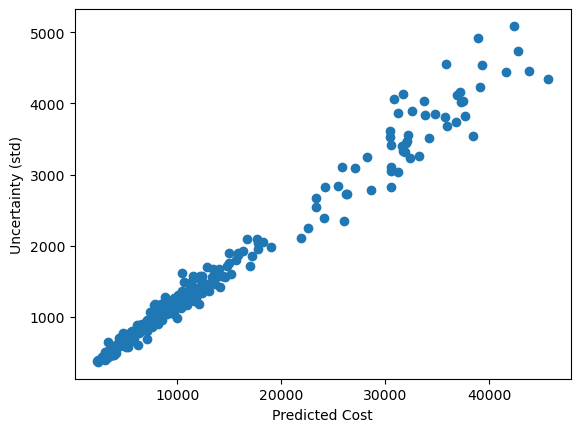

In [45]:
plt.scatter(mean_pred, std_pred)
plt.xlabel("Predicted Cost")
plt.ylabel("Uncertainty (std)")
plt.show()